# Notebook to work on proteins phylogeny
To be used with the Python functions in tools_for_phylogeny.py and tools_for_internet.py. Put these files in the same directory as this notebook.
#### Imports

In [1]:
import tools_for_phylogeny as tools
import tools_for_internet as internet

from pathlib import Path
p = Path('.') # this line set path as your current directory

Below, is a mock workflow that shows how to use these tools.

## Sanity check on 'seq_01_GST.txt'.
First of all, let's check the sequences you already found.

In [ ]:
file_path = p / 'GST' / 'align_01_GST_seq_01.txt' # alignment of the sequences in 'seq_01_GST.txt'

In fact, it could be .aln, .fa, ... as long as you have: $\\$
\>seq_name_1 $\\$
---------XXXXX----XXX--- $\\$
\>seq_name_2 $\\$
---XXX---XXXXX----XXX--- $\\$
\>seq_name_3 $\\$
---------XXXXX--XXX----- $\\$
...

In [ ]:
aligned_data = tools.load_from_txt(file_path) # if 2 sequences have the same name, it will tell you

Threshold >= 0.99


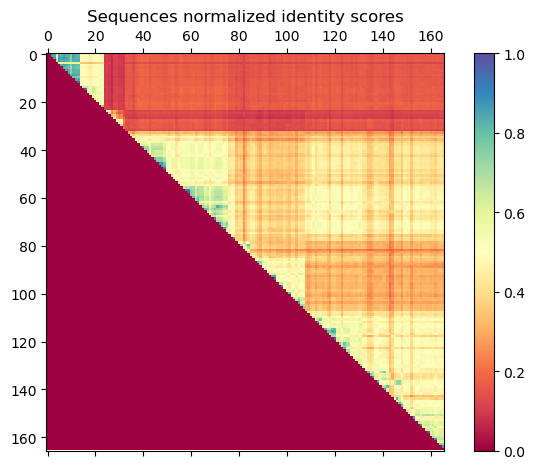

In [ ]:
nocuts_99match = tools.compare_dataset_identity(aligned_data, verbose=True, visual=True)

If you have very close sequences, you can check the mismatch using
>tools.spot_mismatch(aligned_seq2check[first_seq], aligned_seq2check[L_keys[second_seq]], verbose = True). $\\$

But you can also do it using SeaView.

## Get new sequences

Let's say you have a set of protein accession numbers and you want to add them to your dataset:

In [ ]:
L_prot_to_add = ['F0WX54', 'J05242', 'Q2UD26', 'Q9LN93', 'NP_565050', 'P22637', 'Q00922', 'XP_005714951']

### Call UniProt

In [ ]:
UniProt_found_prot, UniProt_not_found = internet.UniProt_get_all_prot(L_prot_to_add)
print('Found ' + str(len(UniProt_found_prot))+ ' proteins.')
print('Failed to get ' + str(len(UniProt_not_found))+ ' proteins.')

Found 25 proteins.
Failed to get 25 proteins.


### Call NCBI on the rest
Or the other way around...

In [ ]:
NCBI_found_prot, NCBI_not_found = internet.NCBI_get_all_prot(list(UniProt_not_found.keys()))
print('Found ' + str(len(NCBI_found_prot))+ ' proteins.')
print('Failed to get ' + str(len(NCBI_not_found))+ ' proteins.')

Found 17 proteins.
Failed to get 8 proteins.


In [ ]:
for prot_id in list(NCBI_not_found.keys()): # just to see what's remaining
    print(prot_id)

Aquca_013_00454.1
J05242
KY511411
NP414845
XP322292
U46081
Spipo0G0174400
AF074951


### Write it down in a new file

In [ ]:
out_path = p / 'GST' / 'seq_01_NewGMC.txt' #same: or .fa, ...
tools.write_to_txt(UniProt_found_prot|NCBI_found_prot, out_path)

## Fuse the new sequences with the old ones

In [ ]:
L_seq_path = [
    p / 'GST' / 'seq_01_GST.txt',
    p / 'GST' / 'seq_01_NewGMC.txt'
]

nb_files = len(L_seq_path) # this array format is useful if you want to fuse a lot of files together: you just add the other files in 'L_seq_path'

In [ ]:
L_dataset = []
for file in range(nb_files):
    L_dataset.append(tools.load_from_txt(L_seq_path[file]))

In [ ]:
fused_dataset = {}
for seq in L_dataset[0]:
    fused_dataset[seq] = L_dataset[0][seq]
print('Nb known seq:', len(fused_dataset))

Nb known seq: 99


In [ ]:
for file in range(1, nb_files):
    new_seq, known_seq = tools.compare_datasets_exact(L_dataset[file], fused_dataset) # comparison based on hash technic
    print('Nb known seq:', len(known_seq), known_seq) # you will see if you picked sequences you already had
    print('NB new seq:', len(new_seq), new_seq)
    for seq in new_seq:
        fused_dataset[seq] = L_dataset[file][seq]

Nb known seq: 0 []
NB new seq: 33 ['>Agaricus_bisporus_GMC_PDH_Q3L1D1 UniProt', '>Albugo_laibachii_GMC_Nc14_F0WX54 UniProt', '>Aspergillus_oryzae_GMC_FOX_Q2UD26 UniProt', '>Arabidopsis_thaliana_GMC_Q9LN93 UniProt', '>Brevibacterium_COX_GMC_sterolicum_P22637 UniProt', '>Candida_boidinii_GMC_AOX_Q00922 UniProt', '>Magallana_gigas_GMC_K1QMH7 UniProt', '>Colletotrichum_gloeosporioides_GMC_GDH_G8E4B5 UniProt', '>Clonorchis_sinensis_GMC_H2KNH4 UniProt', '>Danio_rerio_GMC_E7EY13 UniProt', '>Gluconobacter_japonicus_GMC_FDH_M1VMF7 UniProt', '>Chromohalobacter_israelensis_GMC_CHD_Q9L4K0 UniProt', '>Homo_sapiens_GMC_Q8NE62 UniProt', '>Hydra_vulgaris_GMC_T2M9M9 UniProt', '>Oryza_sativa_GMC_Q9M4V5 UniProt', '>Pichia_angusta_GMC_AOX_P04841 UniProt', '>Phanerodontia_chrysosporium_GMC_POX_Q6QWR1 UniProt', '>Prunus_dulcis_GMC_HNL_O24243 UniProt', '>Phytophthora_nicotianae_GMC_W2PSU1 UniProt', '>Rhizobium_sp_GMC_CKO_GIN611_G9ILI7 UniProt', '>Streptomyces_sp_GMC_COX_P12676 UniProt', '>Sphaerobolus_stella

In [ ]:
len(fused_dataset)

132

In [ ]:
file_path = p / 'GST' / 'seq_02_GST.txt'
tools.write_to_txt(fused_dataset, file_path)

## Redo a sanity check on 'seq_02_GST.txt'.
Because the function
>tools.compare_datasets_exact() $\\$

is very sensitive, so it may miss identical sequences anyway.

In [ ]:
file_path = p / 'GST' / 'align_01_GST_seq_02.txt' # alignment on the data fused just above

In [ ]:
aligned_data = tools.load_from_txt(file_path)

Threshold >= 0.99
1.0 >Pelagomonas_calceolata_CER_CAH0367128.1 NCBI >Pelagomonas_calceolata_cer3_CAH0367128.1 NCBI
1.0 >Aureococcus_anophagefferens_CER_KAH8059732.1 NCBI >Aureococcus_anophagefferens_cer3_KAH8059732.1 NCBI


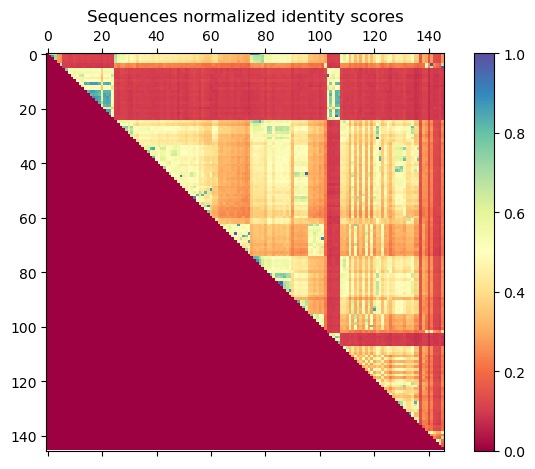

In [ ]:
nocuts_99match = tools.compare_dataset_identity(aligned_data, verbose=True, visual=True)

## Put shorter names to compute on ATCG cluster

ATGC cluster from Montpellier is using alignment with Phylip format, that cuts sequence names at a certain length (30 characters). Thus, a lot of information is lost, and it's difficult to distinguish sequences from the same species if the details and protein identifiers are cut.

### Encode

In [ ]:
dir_path = p / 'GST'
file_name = 'seq_02_GST.txt'

In [ ]:
internet.ATGC_encode(dir_path, file_name)

Please consider renaming the following sequences:
>@!PsuCER1/3_Protsul1175_1|2048821@
>@!MkrCER1/3_Meskra658_1|1389512@


If you have protein name too long, you have to rename them by hand. Just open the reverse_seq_02_GST_short.json and the seq_02_GST_short.txt in a text editor, and edit the short name so it's shorter than 30 characters.

Then you open the seq_02_GST_short.txt in SeaView, align the sequences and export it in align_02_GST_seq_02.phy, send it to ATGC cluster to compute the tree.

### Decode

In [ ]:
dir_path = p / 'GST'
tree_name = 'align_02_gst_short_seq_02_phy_phyml_tree.txt' # the tree you get from ATGC cluster /!\ not the visualization but the proper data file
reverse_name = 'reverse_seq_02_GST_short.json' # the decoding table

In [ ]:
internet.ATGC_decode(dir_path, tree_name, reverse_name)

#### Regroup sequences based on the tree

In [ ]:
dir_path = p / 'GST'
seq_name = 'seq_02_GST.txt'
tree_name = 'tree_02_GST_seq_02_phy_phyml_align_01.txt'

In [ ]:
tools.sort_seq_by_tree(dir_path, seq_name, tree_name)

Now you should have a file seq_02_GST_sorted.txt with the sequences in the same order as they appear in the tree (or reverse direction because it changes between SeaView visualizer and FigTree).

Below are some other functions that you could find useful to rename automatically the sequences you get from NCBI into "Group_species_details__protnb database ..."
>tools.rename_NCBI_sequence(source_path, output_path, details='') $\\$

with details you can add '_GST' or other things in front of the protein identifier $\\$

>tools.add_details(name, newdetails) $\\$
>tools.add_details_to_file(in_path, out_path, newdetails)